In [1]:
# 1. IMPORT LIBRARIES
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# 2. LOAD DATA
df = pd.read_excel("/kaggle/input/instagram-data/instagram_dashboard_data.xlsx")

In [3]:
# 3. PREVIEW DATA
print("Initial data shape:", df.shape)
df.head()

Initial data shape: (61, 13)


,Date,Media ID,Media caption,Media product type,Media impressions,Media reach,Like count,Comments count,Shares,Video views,Unique saves,Engagements,Engagement Rate
0,2025-01-19,17902204887015250,Comment ‘CLASS’ to sign up to my free mastercl...,FEED,868,814,10,8,1,0,2,19,0.023342
1,2025-01-18,18071205646706820,Comment ‘CLASS’ to sign up to my free mastercl...,FEED,741,695,8,2,0,0,1,10,0.014388
2,2025-01-17,18027615518313512,Comment ‘CLASS’ to sign up to my free mastercl...,FEED,1821,1666,24,14,0,0,13,38,0.022809
3,2025-01-16,18034591967437472,Comment ‘CLASS’ to sign up to my free mastercl...,REELS,0,1280,13,27,1,0,5,41,0.032031
4,2025-01-15,18012211340694190,Comment ‘CLASS’ to sign up to my free mastercl...,REELS,0,753,6,8,1,0,2,15,0.019920


In [4]:
# 4. DATA CLEANING
df.dropna(subset=['Date', 'Media reach'], inplace=True)
df['Date'] = pd.to_datetime(df['Date'])
df['Engagements'] = df['Like count'] + df['Comments count'] + df['Shares']
df['Engagement Rate'] = df['Engagements'] / df['Media reach']
df['Engagement Rate'] = df['Engagement Rate'].fillna(0)


In [6]:
# 5. BASIC ANALYSIS
# Average engagement rate
avg_eng_rate = df['Engagement Rate'].mean()
print(f" Average Engagement Rate: {avg_eng_rate:.2%}")


 Average Engagement Rate: 4.25%


In [7]:
# Top-performing post
top_post = df.loc[df['Engagements'].idxmax()]
print("\n Top Performing Post:")
print(top_post[['Media caption', 'Engagements', 'Like count', 'Comments count', 'Shares']])



 Top Performing Post:
Media caption     8 reminders you need to hear today as a divorc...
Engagements                                                     470
Like count                                                      430
Comments count                                                   40
Shares                                                            0
Name: 28, dtype: object


In [8]:
# 6. VISUALIZATION SETUP
sns.set(style="whitegrid")
plt.figure(figsize=(12, 5))

<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

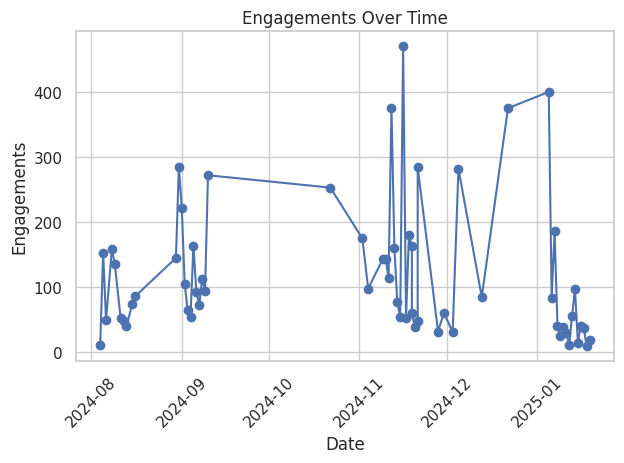

In [9]:
# Line chart: Engagements over time
df_sorted = df.sort_values('Date')
plt.plot(df_sorted['Date'], df_sorted['Engagements'], marker='o')
plt.title('Engagements Over Time')
plt.xlabel('Date')
plt.ylabel('Engagements')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


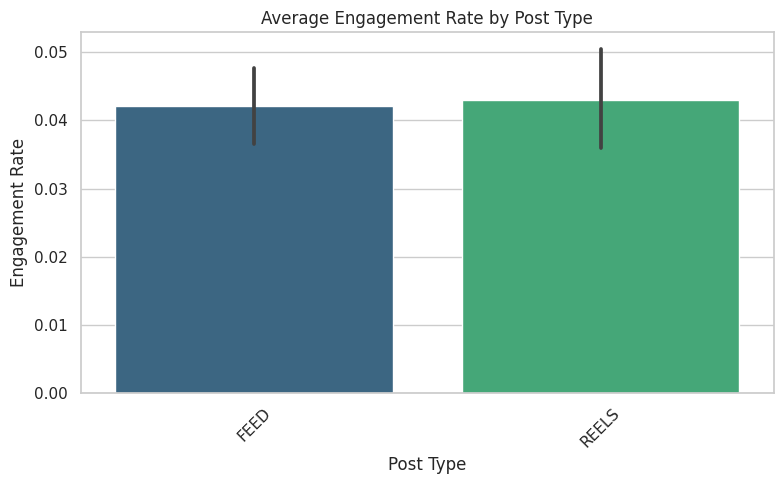

In [11]:
# Bar Chart: Avg Engagement Rate by Post Type
plt.figure(figsize=(8, 5))
sns.barplot(
    data=df,
    x='Media product type',
    y='Engagement Rate',
    estimator='mean',
    palette='viridis'
)
plt.title('Average Engagement Rate by Post Type')
plt.ylabel('Engagement Rate')
plt.xlabel('Post Type')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()